### Pion quasi-DA

10 configurations of HotQCD l4864 ensemble.

In [1]:
import numpy as np
from lametlat.utils.plot_settings import *
from lametlat.utils.resampling import *
from lametlat.preprocess.read_raw import pt2_to_meff

In [2]:
data = np.load('/home/jinchen/git/lat-software/pyquda_benchmark/temp/pion_DA_Nconf10.npz')
print(data['pion_DA'].shape)

point_pion_jk = jackknife(data['pion_DA'])
point_pion_jk_avg = jk_ls_avg(point_pion_jk)
print(point_pion_jk_avg.shape)

(10, 48, 64)
(48, 64)


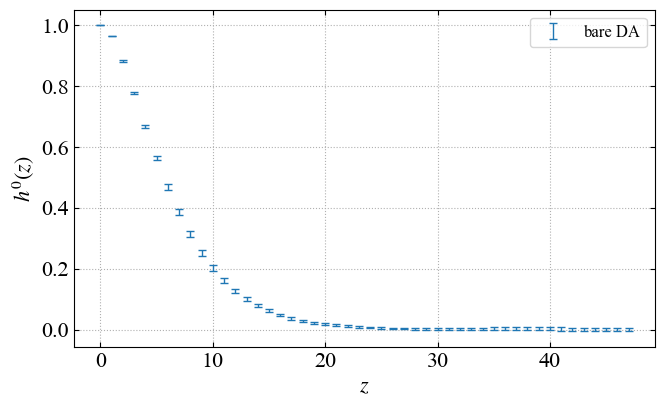

In [3]:
fix_t = 10
z_list = list(range(48))

bare_da = []
for z in z_list:
    bare_da.append(point_pion_jk_avg[z][fix_t])
bare_da = np.array(bare_da)
bare_da = bare_da / bare_da[0]

fig, ax = default_plot()
ax.errorbar(z_list, gv.mean(bare_da), yerr=gv.sdev(bare_da), label="bare DA", **errorb)
ax.legend(**fs_small_p)
ax.set_xlabel(r"$z$", **fs_p)
ax.set_ylabel(r"$h^0(z)$", **fs_p)
plt.tight_layout()
plt.show()

/home/jinchen/git/package/LaMETLat/lametlat/preprocess/read_raw.py:70: RuntimeWarning: invalid value encountered in sqrt
  meff_array = np.arccosh( (pt2_array[2:] + pt2_array[:-2]) / (2 * pt2_array[1:-1]) ) #! This is not always correct.


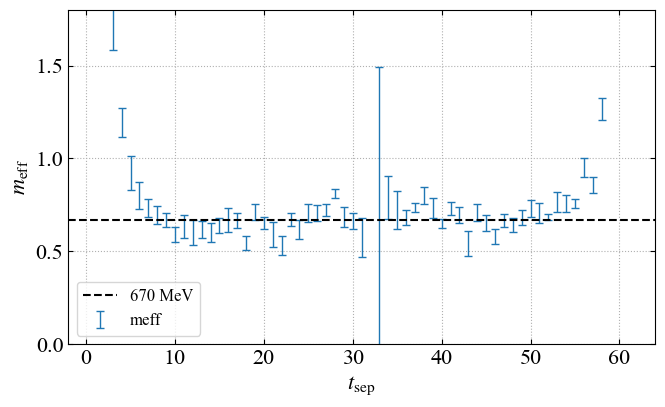

In [4]:
meff = pt2_to_meff(point_pion_jk_avg[0], boundary="periodic") * 0.197 / 0.06 # GeV

fig, ax = default_plot()
ax.errorbar(np.arange(len(meff)), gv.mean(meff), yerr=gv.sdev(meff), label="meff", **errorb)
ax.axhline(0.67, color="black", linestyle="--", label="670 MeV")
ax.legend(**fs_small_p)
ax.set_xlabel(r"$t_{\mathrm{sep}}$", **fs_p)
ax.set_ylabel(r"$m_{\mathrm{eff}}$", **fs_p)
ax.set_ylim(0, 1.8)
plt.tight_layout()
plt.show()